In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

In [2]:
data = pd.read_csv("shop_smart_ecommerce.csv")

In [3]:
data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


<Axes: xlabel='Month', ylabel='Count'>

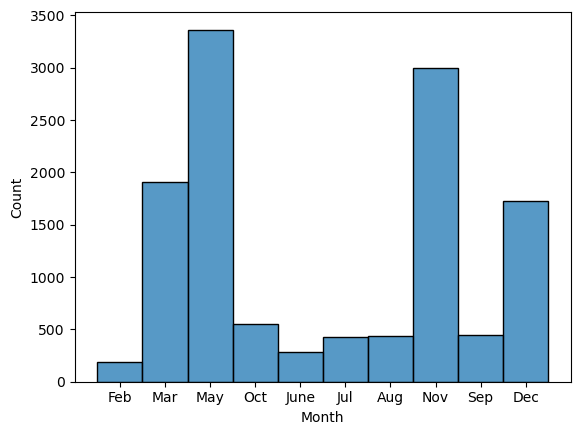

In [4]:
sns.histplot(
    data = data,
    x = 'Month',
    bins = 12   
)

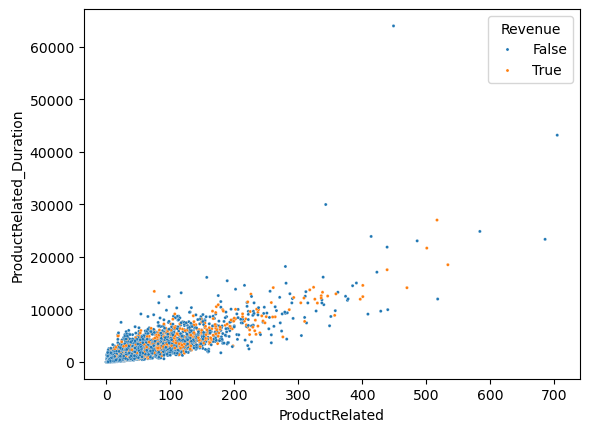

In [5]:
sns.scatterplot(
    data = data,
    x = 'ProductRelated',
    y = 'ProductRelated_Duration',
    hue = 'Revenue',
    s = 5
)
plt.show()

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [7]:
data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [8]:
data['Revenue'] = data['Revenue'].astype(int)

In [9]:
X = data.drop('Revenue', axis = 1)
y = data['Revenue']

In [10]:
X.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True


In [11]:
num_features = X.select_dtypes(include = 'number').columns
cat_features = X.select_dtypes(include = 'object').columns

In [12]:
cat_features

Index(['Month', 'VisitorType'], dtype='object')

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state = 42, test_size = 0.2, stratify = y
)

In [14]:
preprocessor = ColumnTransformer(
    transformers = [
        ('scaler', StandardScaler(), num_features),
        ('OneHot', OneHotEncoder(handle_unknown = 'ignore'), cat_features)
    ]
)

In [15]:
dT = DecisionTreeClassifier(
    max_depth = 10,
    min_samples_leaf = 30,
    class_weight = 'balanced',
    random_state = 42
)

In [16]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', dT)
])

In [17]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler', ...), ('OneHot', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
y_pred = pipeline.predict(X_test)

In [19]:
print(f"F1 score : {f1_score(y_test, y_pred)}")
print("Classification Report", classification_report(y_test, y_pred))
print("Confusion Matrix : ", confusion_matrix(y_test, y_pred))

F1 score : 0.6343434343434343
Classification Report               precision    recall  f1-score   support

           0       0.96      0.86      0.91      2084
           1       0.52      0.82      0.63       382

    accuracy                           0.85      2466
   macro avg       0.74      0.84      0.77      2466
weighted avg       0.89      0.85      0.87      2466

Confusion Matrix :  [[1790  294]
 [  68  314]]


## Hyperparameter Tuning

In [20]:
params = {
    "model__max_depth" : [4, 6, 8, 10, 12],
    "model__min_samples_leaf" : [20, 30, 40, 50],
    "model__ccp_alpha" : [0.01, 0.02, 0.05, 0.1, 0.4, 0.8, 1]
}

grid = GridSearchCV(
    pipeline,
    param_grid = params,
    scoring = 'f1',
    cv = 5,
    verbose = True
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 140 candidates, totalling 700 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__ccp_alpha': [0.01, 0.02, ...], 'model__max_depth': [4, 6, ...], 'model__min_samples_leaf': [20, 30, ...]}"
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('scaler', ...), ('OneHot', ...)]"


In [21]:
y_pred = grid.predict(X_test)

print(f"F1 score : {f1_score(y_test, y_pred)}")
print("Classification Report", classification_report(y_test, y_pred))
print("Confusion Matrix : ", confusion_matrix(y_test, y_pred))

F1 score : 0.6485310119695321
Classification Report               precision    recall  f1-score   support

           0       0.96      0.89      0.92      2084
           1       0.55      0.78      0.65       382

    accuracy                           0.87      2466
   macro avg       0.76      0.83      0.78      2466
weighted avg       0.89      0.87      0.88      2466

Confusion Matrix :  [[1845  239]
 [  84  298]]


In [25]:
print(grid.best_score_)
print(grid.best_params_)

0.6682425573085669
{'model__ccp_alpha': 0.05, 'model__max_depth': 3, 'model__min_samples_split': 15}
